# Week 3: USB Speaker and Audio Output Control with Raspberry Pi

This notebook explains how to connect and test a USB speaker with the Raspberry Pi Zero 2 W. The setup uses a USB OTG cable and a USB speaker so that the Raspberry Pi can produce audio output.

The main focus of this notebook is to establish the USB audio-output connection, check whether the speaker is detected, test playback, generate a short audio signal using Python, play it through the USB speaker, visualize the waveform, and use a simple fuzzy-style audio alert example.

## 1. Overview

In this week’s setup, we use a USB speaker as an external audio-output device for the Raspberry Pi Zero 2 W. The Raspberry Pi sends audio output through the USB connection, and the USB speaker plays the generated or selected sound.

This template follows the same practical workflow used in earlier weeks:

1. Prepare the Raspberry Pi environment.
2. Connect the hardware.
3. Check whether the device is detected.
4. Test the output.
5. Generate or use simple data.
6. Application of Computing-with-Words / fuzzy-style example.

In this notebook, the output is sound. The final example uses a numerical input level and converts it into linguistic labels such as **Low**, **Medium**, and **High**. Based on the label, the Raspberry Pi plays a different audio alert.

<div style="display: flex; justify-content: center;">
  <img src="USB_Audio_Device.jpg" width="450">
</div>

<div style="text-align: center;">
  <b>Figure 1:</b> USB speaker audio-output setup with Raspberry Pi Zero 2 W.
</div>

## 2. Learning Objectives

By the end of this notebook, students should be able to:

1. Identify the required components for a USB speaker setup.
2. Connect a USB speaker to the Raspberry Pi Zero 2 W using a USB OTG cable.
3. Access the Raspberry Pi through the existing SSH/Jupyter workflow.
4. Check whether the USB audio device is detected.
5. List available audio playback devices.
6. Test speaker output using ALSA commands.
7. Generate a simple test audio file using Python.
8. Play the generated audio through the USB speaker.
9. Visualize the generated audio waveform.
10. Use a simple fuzzy-style rule system to select different audio alerts.

## 3. Required Components

The following components are used in this setup:

| Component | Purpose |
|---|---|
| Raspberry Pi Zero 2 W | Main computing device used to run commands and Python code |
| MicroSD card with Raspberry Pi OS | Stores the operating system and project files |
| USB OTG cable | Allows the Raspberry Pi Zero 2 W to connect to USB devices |
| USB speaker | Plays the audio output generated by the Raspberry Pi |
| Power supply | Powers the Raspberry Pi |


The USB speaker used in this setup is an output device. Therefore, this notebook focuses on **audio playback and audio-output control**. Microphone recording is included only as an optional extension at the end.

## 4. Component Roles

Each component has a specific role in the setup:

**Raspberry Pi Zero 2 W**  
The Raspberry Pi is the main device. It runs the operating system, detects the USB speaker, executes terminal commands, and runs the Python code.

<div style="display: flex; justify-content: center;">
  <img src="Raspberry_Pi.png" width="450">
</div>

<div style="text-align: center;">
  <b>Raspberry Pi Zero 2 W.
</div>

**MicroSD card**  
The microSD card contains Raspberry Pi OS and stores the project folder, notebook file, generated audio files, and output results.

<div style="display: flex; justify-content: center;">
  <img src="SD-CardInReader.jpg" width="450">
</div>

<div style="text-align: center;">
  <b>MicroSD card.
</div>

**USB OTG cable**  
The Raspberry Pi Zero 2 W uses a micro-USB port for USB devices. The OTG cable allows a normal USB-A device, such as a USB speaker, to be connected to the Raspberry Pi.

<div style="display: flex; justify-content: center;">
  <img src="usb_otg _cable.png" width="450">
</div>

<div style="text-align: center;">
  <b>USB OTG cable.
</div>

**USB speaker**  
The USB speaker is used as the audio-output device. After it is detected by the Raspberry Pi, it can play test sounds and Python-generated audio alerts.

<div style="display: flex; justify-content: center;">
  <img src="usb_speaker.jpg" width="450">
</div>

<div style="text-align: center;">
  <b>USB speaker.
</div>


## 6. Hardware Connection

The physical setup for this experiment is simple. The USB speaker is connected directly to the Raspberry Pi Zero 2 W through the USB OTG cable.

```text
Raspberry Pi Zero 2 W
        ↓
USB OTG cable
        ↓
USB speaker
```

After this connection is completed, power on the Raspberry Pi. The USB speaker should receive power through the USB connection and should be detected as an audio-output device by the Raspberry Pi.


## 7. Raspberry Pi Access Reminder

The USB speaker is connected directly to the Raspberry Pi. Therefore, the audio-checking commands and Python audio-output code should be executed on the Raspberry Pi environment.

The Raspberry Pi access workflow was introduced in the earlier setup notebook. In this experiment, the same access method is reused.

A typical SSH connection from the laptop to the Raspberry Pi is:

```bash
ssh pi@cwpi-zero2w.local
```

If the hostname does not work, use the Raspberry Pi IP address:

```bash
ssh pi@<raspberry-pi-ip-address>
```




## 8. Working Folder for the Audio Experiment

For this experiment, one working folder is recommended to keep the notebook, generated audio files, and output files together.

This keeps the audio files organized and avoids mixing them with files from other pi experiments.

Run the following commands in the Raspberry Pi terminal:

```bash
mkdir -p ~/usb_audio_work
cd ~/usb_audio_work



## 9. Checking Whether the USB Speaker Is Detected

After the USB speaker is connected to the Raspberry Pi through the USB OTG cable, the first step is to check whether the Raspberry Pi can detect the USB device.

The command `lsusb` lists the USB devices connected to the Raspberry Pi. If the USB speaker is detected correctly, it should appear in the list as a USB audio device, speaker device, or a device from the speaker manufacturer.

Run the following cell to check the connected USB devices.

In [24]:
import subprocess
import shutil

def run_command(command):
    """Run a terminal command and print the output clearly."""
    print(f"$ {command}")
    print("-" * 60)
    
    try:
        result = subprocess.run(
            command,
            shell=True,
            text=True,
            capture_output=True,
            timeout=15
        )
        
        if result.stdout.strip():
            print(result.stdout)
        if result.stderr.strip():
            print(result.stderr)
            
        if result.returncode == 0:
            print("Command completed successfully.")
        else:
            print("Command finished with a warning or error. Check the message above.")
            
    except subprocess.TimeoutExpired:
        print("Command took too long and was stopped.")
    except Exception as e:
        print("Error while running command:", e)

run_command("lsusb")

$ lsusb
------------------------------------------------------------
Bus 001 Device 001: ID 1d6b:0002 Linux Foundation 2.0 root hub
Bus 001 Device 002: ID 4c4a:4155 Jieli Technology UACDemoV1.0

Command completed successfully.


### Expected Output, Meaning and Troubleshooting

After running `lsusb`, the Raspberry Pi should show the USB devices currently connected.

For this setup, a successful output should include something similar to:

```text
Bus 001 Device 001: ID 1d6b:0002 Linux Foundation 2.0 root hub
Bus 001 Device 003: ID 4c4a:4155 Jieli Technology UACDemoV1.0
```

The **Linux Foundation 2.0 root hub** is the Raspberry Pi USB system itself. This usually appears even when no external USB device is connected.

The **Jieli Technology UACDemoV1.0** entry represents the connected USB speaker. This confirms that the Raspberry Pi has detected the USB speaker through the OTG cable.

If the **Jieli Technology UACDemoV1.0** device does not appear, the speaker is not detected correctly. In that case, check that the speaker is connected to the **USB** port through the OTG cable, while the Raspberry Pi power cable is connected to **PWR IN**. Then unplug and reconnect the speaker, wait a few seconds, and run the cell again.

When both entries appear, the USB speaker connection is ready for the next step.

## 10. Checking Available Playback Devices

After confirming that the USB speaker is connected, the next step is to check the available audio playback devices.

The command `aplay -l` lists the playback hardware devices detected by ALSA. **ALSA stands for Advanced Linux Sound Architecture** and is commonly used in Linux systems for audio input and output.

In this experiment, the important point is to confirm that the USB speaker appears as one of the playback devices.

Run the following cell to list the available playback devices.

In [25]:
run_command("aplay -l")

$ aplay -l
------------------------------------------------------------
**** List of PLAYBACK Hardware Devices ****
card 0: vc4hdmi [vc4-hdmi], device 0: MAI PCM i2s-hifi-0 [MAI PCM i2s-hifi-0]
  Subdevices: 1/1
  Subdevice #0: subdevice #0
card 1: UACDemoV10 [UACDemoV1.0], device 0: USB Audio [USB Audio]
  Subdevices: 1/1
  Subdevice #0: subdevice #0

Command completed successfully.


### Expected Playback Device Output, Meaning and Troubleshooting

After running `aplay -l`, the Raspberry Pi should list the available audio playback devices.

For this setup, a successful output should look similar to:

```text
card 0: vc4hdmi [vc4-hdmi], device 0: MAI PCM i2s-hifi-0
card 1: UACDemoV10 [UACDemoV1.0], device 0: USB Audio
```

Here, **card 0** usually refers to the Raspberry Pi HDMI audio output.

The important device for this experiment is:

```text
card 1: UACDemoV10 [UACDemoV1.0], device 0: USB Audio
```

This means the USB speaker is detected as an audio playback device. In this setup, the USB speaker can be accessed as:

```text
plughw:1,0
```

Therefore, the playback commands in this notebook use:

```bash
-D plughw:1,0
```

This sends the sound directly to the USB speaker instead of another output such as HDMI.

If the USB audio device does not appear here, first check the `lsusb` output again. The USB speaker must be detected as a USB device before it can appear as an audio playback device.

## 11. Testing Basic Speaker Output

Once the USB speaker appears as a playback device, the speaker output can be tested.

The command `speaker-test` sends a test sound to the audio output device. This confirms that the Raspberry Pi can send audio to the USB speaker.

In this notebook, the test is limited to a short playback so that it does not continue running for too long.

When this cell is executed on the Raspberry Pi, a short test sound should be heard from the USB speaker.

In [27]:
run_command("speaker-test -D plughw:1,0 -t sine -f 700 -c 1 -l 1")

$ speaker-test -D plughw:1,0 -t sine -f 700 -c 1 -l 1
------------------------------------------------------------

speaker-test 1.2.14

Playback device is plughw:1,0
Stream parameters are 48000Hz, S16_LE, 1 channels
Sine wave rate is 700.0000Hz
Rate set to 48000Hz (requested 48000Hz)
Buffer size range from 96 to 96000
Period size range from 48 to 48000
Periods = 4
was set period_size = 12000
was set buffer_size = 48000
 0 - Front Left
Time per period = 2.000060

Command completed successfully.


## 12. Creating Test Audio Signals in Python

After testing the speaker with ALSA commands, the next step is to create audio files directly using Python.

In this section, three simple tones are generated:

- `low_tone.wav`
- `medium_tone.wav`
- `high_tone.wav`

Each tone has a different frequency. These files will later be used for the fuzzy-style audio alert example.

In [28]:
from pathlib import Path
import numpy as np
from scipy.io import wavfile

# Use the current notebook folder as the working location
work_dir = Path.cwd()

sample_rate = 44100
duration = 1.0  # seconds

def create_tone(filename, frequency, duration=1.0, sample_rate=44100, amplitude=0.4):
    """
    Create a sine-wave audio tone and save it as a WAV file.
    """
    t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
    signal = amplitude * np.sin(2 * np.pi * frequency * t)
    
    # Convert from float signal to 16-bit PCM format
    audio_data = np.int16(signal * 32767)
    
    file_path = work_dir / filename
    wavfile.write(file_path, sample_rate, audio_data)
    
    return file_path

low_tone = create_tone("low_tone.wav", frequency=300)
medium_tone = create_tone("medium_tone.wav", frequency=600)
high_tone = create_tone("high_tone.wav", frequency=1000)

print("Audio files created:")
print(low_tone)
print(medium_tone)
print(high_tone)

Audio files created:
/home/pi/cw_jupyter/week3_usb_audio/low_tone.wav
/home/pi/cw_jupyter/week3_usb_audio/medium_tone.wav
/home/pi/cw_jupyter/week3_usb_audio/high_tone.wav


## 13. Playing the Generated Audio Files

The generated WAV files can now be played through the USB speaker.

The command `aplay` is used to play WAV files from the Raspberry Pi terminal. In this notebook, Python is used to call the same command.

Run the following cell and listen to the three tones from the USB speaker.

In [29]:
def play_audio_file(file_path):
    """
    Play a WAV audio file through the USB speaker.
    The USB speaker is detected as card 1, device 0.
    """
    file_path = Path(file_path)
    
    if not file_path.exists():
        print(f"File not found: {file_path}")
        return
    
    command = f'aplay -D plughw:1,0 "{file_path}"'
    run_command(command)

print("Playing low tone...")
play_audio_file("low_tone.wav")

print("\nPlaying medium tone...")
play_audio_file("medium_tone.wav")

print("\nPlaying high tone...")
play_audio_file("high_tone.wav")

Playing low tone...
$ aplay -D plughw:1,0 "low_tone.wav"
------------------------------------------------------------
Playing WAVE 'low_tone.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono

Command completed successfully.

Playing medium tone...
$ aplay -D plughw:1,0 "medium_tone.wav"
------------------------------------------------------------
Playing WAVE 'medium_tone.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono

Command completed successfully.

Playing high tone...
$ aplay -D plughw:1,0 "high_tone.wav"
------------------------------------------------------------
Playing WAVE 'high_tone.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono

Command completed successfully.


## 14. Visualizing the Audio Waveform

The audio files created in Python can also be visualized as waveforms.

A waveform shows how the sound signal changes over time. This is useful because it allows us to see the generated signal before or after playing it through the USB speaker.

In this section, the three generated tones are loaded and displayed as waveform plots.

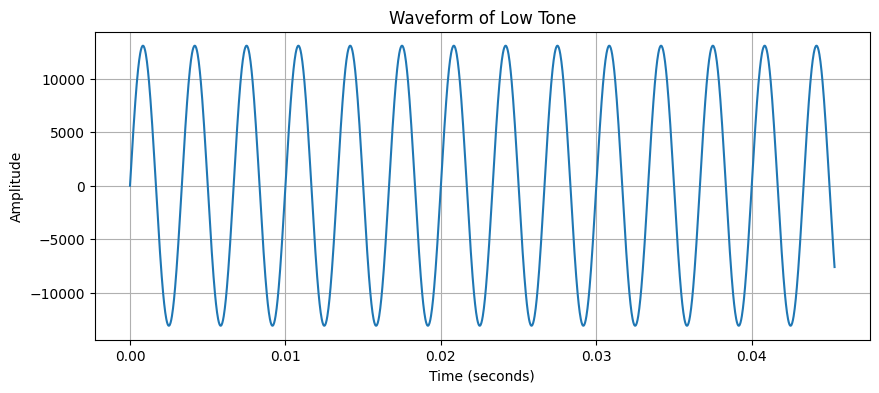

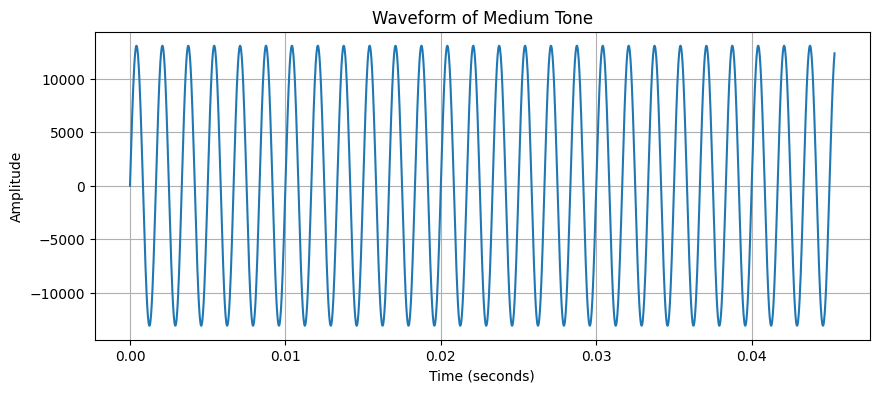

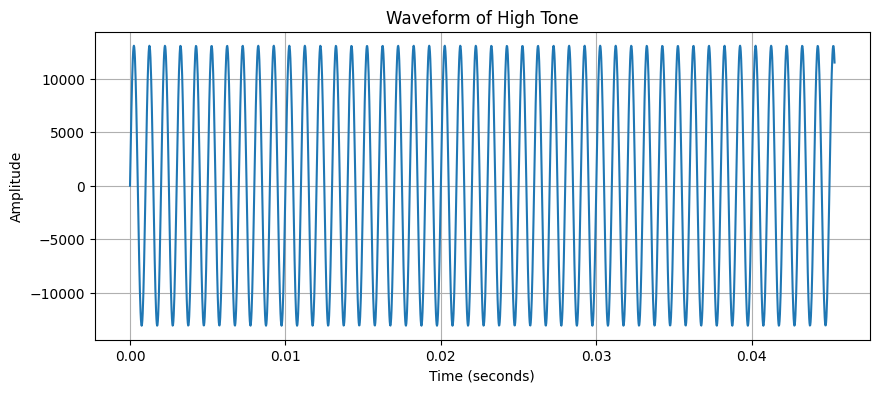

In [30]:
import matplotlib.pyplot as plt

def plot_waveform(filename, title):
    """
    Load a WAV file and plot its waveform.
    """
    file_path = work_dir / filename
    rate, data = wavfile.read(file_path)
    
    duration = len(data) / rate
    time_axis = np.linspace(0, duration, len(data), endpoint=False)
    
    plt.figure(figsize=(10, 4))
    plt.plot(time_axis[:2000], data[:2000])
    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.show()

plot_waveform("low_tone.wav", "Waveform of Low Tone")
plot_waveform("medium_tone.wav", "Waveform of Medium Tone")
plot_waveform("high_tone.wav", "Waveform of High Tone")

## 15. Fuzzy-Style Audio Alert Classification

In this section, the generated audio tones are connected to a simple Computing with Words idea.

A numerical alert value is converted into a linguistic label:

| Alert Value | Linguistic Label | Audio Meaning |
|---|---|---|
| 0–30 | Low | One low alert tone |
| 31–70 | Medium | Two medium alert tones |
| 71–100 | High | Three quick high alert tones |

This is a simple classification-based alert example. The goal is to show how a Raspberry Pi can convert a numerical value into a meaningful word, and then use that word to choose an audio output.

For example, if the input value is high, the Raspberry Pi does not only print the word **High**. It also plays a stronger alert pattern through the USB speaker.

This section only explains and checks the logic. The actual interactive sound output happens in Section 16.

In [41]:
import time
from pathlib import Path

def classify_alert_level(value):
    """
    Convert a numerical alert value into a linguistic label.
    """
    if value < 0 or value > 100:
        raise ValueError("Alert value must be between 0 and 100.")
    
    if value <= 30:
        return "Low"
    elif value <= 70:
        return "Medium"
    else:
        return "High"


def get_audio_pattern_for_label(label):
    """
    Select the audio file and number of repetitions for each label.
    """
    if label == "Low":
        return "low_tone.wav", 1
    elif label == "Medium":
        return "medium_tone.wav", 2
    elif label == "High":
        return "high_tone.wav", 3
    else:
        raise ValueError("Unknown alert label.")


def play_alert_pattern(audio_file, repetitions, pause=0.25):
    """
    Play an audio file one or more times through the USB speaker.
    """
    for i in range(repetitions):
        play_audio_file(audio_file)
        time.sleep(pause)


# Example classification check
example_values = [20, 55, 85]

for value in example_values:
    label = classify_alert_level(value)
    audio_file, repetitions = get_audio_pattern_for_label(label)
    
    print(f"Input value: {value}")
    print(f"Linguistic label: {label}")
    print(f"Selected audio file: {audio_file}")
    print(f"Number of alert tones: {repetitions}")
    print("-" * 40)

Input value: 20
Linguistic label: Low
Selected audio file: low_tone.wav
Number of alert tones: 1
----------------------------------------
Input value: 55
Linguistic label: Medium
Selected audio file: medium_tone.wav
Number of alert tones: 2
----------------------------------------
Input value: 85
Linguistic label: High
Selected audio file: high_tone.wav
Number of alert tones: 3
----------------------------------------


## 16. Running the Full Audio Output Example

In this section, the full audio alert example is executed.

The user enters an alert value between **0 and 100**. The Raspberry Pi classifies the value into a linguistic label and plays the corresponding alert sound pattern through the USB speaker.

The alert pattern is:

```text
Low value    → one low tone
Medium value → two medium tones
High value   → three quick high tones

In [43]:
def run_audio_alert():
    """
    Ask the user for an alert value, classify it, and play the matching audio pattern.
    """
    value = float(input("Enter an alert value between 0 and 100: "))
    
    label = classify_alert_level(value)
    audio_file, repetitions = get_audio_pattern_for_label(label)
    
    print("Audio Alert Result")
    print("-" * 40)
    print(f"Input value: {value}")
    print(f"Linguistic label: {label}")
    print(f"Selected audio file: {audio_file}")
    print(f"Number of alert tones: {repetitions}")
    print("-" * 40)
    
    play_alert_pattern(audio_file, repetitions)

run_audio_alert()

Enter an alert value between 0 and 100:  88


Audio Alert Result
----------------------------------------
Input value: 88.0
Linguistic label: High
Selected audio file: high_tone.wav
Number of alert tones: 3
----------------------------------------
$ aplay -D plughw:1,0 "high_tone.wav"
------------------------------------------------------------
Playing WAVE 'high_tone.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono

Command completed successfully.
$ aplay -D plughw:1,0 "high_tone.wav"
------------------------------------------------------------
Playing WAVE 'high_tone.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono

Command completed successfully.
$ aplay -D plughw:1,0 "high_tone.wav"
------------------------------------------------------------
Playing WAVE 'high_tone.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono

Command completed successfully.


## 17. Real-World Example: Audio Feedback for a Monitoring System

In this example, the Raspberry Pi uses the USB speaker to give audio feedback for a simple monitoring situation.

A monitoring system may observe many kinds of situations, such as a machine status, an environment condition, or a sensor reading. Sometimes the system does not only need to know whether something is low or high. It may also need to know how sure it is and how quickly the user should react.

For this reason, this example uses three input values:

- **Risk level**: How serious is the situation?
- **Confidence level**: How sure is the system about the situation?
- **Urgency level**: How quickly should the user react?

The Raspberry Pi uses these values to choose an attention level and then plays a matching sound pattern through the USB speaker.

| Attention Level | Meaning | Audio Pattern |
|---|---|---|
| Calm | The situation is stable | One low tone |
| Caution | The situation should be noticed | Two medium tones |
| Warning | The user should pay attention | Three medium tones |
| Critical | The user should react quickly | Four fast high tones |

This example shows how fuzzy-style reasoning can be used in a practical way. The Raspberry Pi does not only play a sound. It chooses the sound based on how the situation is understood.

In [42]:
import time

def fuzzy_low(x):
    """
    Low membership:
    Strongly low near 0, gradually decreases until 50.
    """
    if x <= 25:
        return 1.0
    elif x < 50:
        return (50 - x) / 25
    else:
        return 0.0


def fuzzy_medium(x):
    """
    Medium membership:
    Strongest near 50, weaker toward 25 and 75.
    """
    if x <= 25 or x >= 75:
        return 0.0
    elif x <= 50:
        return (x - 25) / 25
    else:
        return (75 - x) / 25


def fuzzy_high(x):
    """
    High membership:
    Starts increasing after 50 and becomes strongly high near 75–100.
    """
    if x <= 50:
        return 0.0
    elif x < 75:
        return (x - 50) / 25
    else:
        return 1.0


def calculate_attention_level(risk, confidence, urgency):
    """
    Calculate fuzzy-style attention levels using simple rules.
    """

    # Fuzzy memberships for each input
    risk_low = fuzzy_low(risk)
    risk_med = fuzzy_medium(risk)
    risk_high = fuzzy_high(risk)

    conf_low = fuzzy_low(confidence)
    conf_med = fuzzy_medium(confidence)
    conf_high = fuzzy_high(confidence)

    urg_low = fuzzy_low(urgency)
    urg_med = fuzzy_medium(urgency)
    urg_high = fuzzy_high(urgency)

    # Simple fuzzy-style rules
    calm = max(
        min(risk_low, urg_low),
        min(risk_low, conf_high)
    )

    caution = max(
        min(risk_med, urg_low),
        min(risk_low, urg_med),
        min(risk_high, conf_low)
    )

    warning = max(
        min(risk_med, urg_med),
        min(risk_high, conf_med),
        min(risk_med, conf_high)
    )

    critical = max(
        min(risk_high, urg_high),
        min(risk_high, conf_high),
        min(risk_med, urg_high, conf_high)
    )

    attention_scores = {
        "Calm": calm,
        "Caution": caution,
        "Warning": warning,
        "Critical": critical
    }

    selected_level = max(attention_scores, key=attention_scores.get)

    return selected_level, attention_scores


def get_attention_audio_pattern(attention_level):
    """
    Select the audio file and repetition pattern for each attention level.
    """
    if attention_level == "Calm":
        return "low_tone.wav", 1, 0.40
    elif attention_level == "Caution":
        return "medium_tone.wav", 2, 0.30
    elif attention_level == "Warning":
        return "medium_tone.wav", 3, 0.20
    elif attention_level == "Critical":
        return "high_tone.wav", 4, 0.10
    else:
        raise ValueError("Unknown attention level.")


def play_attention_pattern(audio_file, repetitions, pause):
    """
    Play the selected audio pattern through the USB speaker.
    """
    for _ in range(repetitions):
        play_audio_file(audio_file)
        time.sleep(pause)


def run_fuzzy_attention_feedback():
    """
    Ask the user for three values and play the matching audio feedback.
    """
    risk = float(input("Enter risk level between 0 and 100: "))
    confidence = float(input("Enter confidence level between 0 and 100: "))
    urgency = float(input("Enter urgency level between 0 and 100: "))

    for value in [risk, confidence, urgency]:
        if value < 0 or value > 100:
            raise ValueError("All values must be between 0 and 100.")

    attention_level, attention_scores = calculate_attention_level(risk, confidence, urgency)
    audio_file, repetitions, pause = get_attention_audio_pattern(attention_level)

    print("Fuzzy Attention Feedback Result")
    print("-" * 50)
    print(f"Risk level: {risk}")
    print(f"Confidence level: {confidence}")
    print(f"Urgency level: {urgency}")
    print()

    print("Attention scores:")
    for level, score in attention_scores.items():
        print(f"{level}: {score:.2f}")

    print()
    print(f"Selected attention level: {attention_level}")
    print(f"Audio file: {audio_file}")
    print(f"Number of tones: {repetitions}")
    print("-" * 50)

    play_attention_pattern(audio_file, repetitions, pause)


run_fuzzy_attention_feedback()

Enter risk level between 0 and 100:  88
Enter confidence level between 0 and 100:  79
Enter urgency level between 0 and 100:  33


Fuzzy Attention Feedback Result
--------------------------------------------------
Risk level: 88.0
Confidence level: 79.0
Urgency level: 33.0

Attention scores:
Calm: 0.00
Caution: 0.00
Critical: 1.00

Selected attention level: Critical
Audio file: high_tone.wav
Number of tones: 4
--------------------------------------------------
$ aplay -D plughw:1,0 "high_tone.wav"
------------------------------------------------------------
Playing WAVE 'high_tone.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono

Command completed successfully.
$ aplay -D plughw:1,0 "high_tone.wav"
------------------------------------------------------------
Playing WAVE 'high_tone.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono

Command completed successfully.
$ aplay -D plughw:1,0 "high_tone.wav"
------------------------------------------------------------
Playing WAVE 'high_tone.wav' : Signed 16 bit Little Endian, Rate 44100 Hz, Mono

Command completed successfully.
$ aplay -D plughw:1,0 "high_to

## 18. Optional Extension: Microphone Recording

The current experiment focuses on USB speaker output because the available hardware is a USB speaker.

If a USB sound card with microphone input or a USB microphone is connected, the setup can be extended to include audio recording.

In that case, the additional steps would be:

1. Connect the USB microphone or USB sound card to the Raspberry Pi.
2. Check recording devices using:

```bash
arecord -l

#Record a short audio sample using:
arecord --format S16_LE --rate 44100 -c1 sample.wav

#Play back the recorded file using:
aplay sample.wav

## 20. Summary

This experiment showed how a USB speaker can be connected to the Raspberry Pi and used as an audio output device.

The Raspberry Pi first detected the USB speaker as a connected USB device and then listed it as an available playback device. After confirming the connection, short test sounds and Python-generated audio tones were played through the speaker.

The generated tones were also visualized as waveforms. This helped connect the sound heard from the speaker with the digital signal created in Python.

The experiment then connected audio output with a simple Computing with Words idea. Numerical values were interpreted using linguistic labels such as **Low**, **Medium**, and **High**, and the Raspberry Pi selected a matching sound pattern.

Finally, the monitoring example showed how audio feedback can support a real-world situation. By using values such as **risk**, **confidence**, and **urgency**, the Raspberry Pi selected an attention level such as **Calm**, **Caution**, **Warning**, or **Critical** and played a corresponding sound pattern.

The main takeaway is that the Raspberry Pi can do more than simply play audio. It can use simple reasoning logic to choose meaningful sound feedback for different situations. This idea can later be extended to sensor-based alerts, interactive devices, or more advanced Computing with Words experiments.